# Scrape ABVD wordlists and loanword annotations

This notebook downloads every language wordlist from the [Austronesian Basic Vocabulary Database (ABVD)](https://abvd.eva.mpg.de/austronesian/word.php), extracts coordinates and annotations, and writes the three requested analysis tables.

Outputs are saved in `python/cognate/output/`:

1. `COGNATE_df_abvd_all_languages.csv` — every ABVD language record, coordinates, and one column per English concept. Multiple forms for the same concept are joined with `; `.
2. `PH_df_abvd_philippine_languages.csv` — Table 1 filtered with the strict geographic bounds `4.5 < latitude < 21` and `115 < longitude < 128`, then wordlists sharing a glottocode are merged.
3. `PH_df_philippine_na_counts.csv` — missing-value counts for every word column, descending.
4. `PH_loan_philippine_loanword_indicators.csv` — Philippine records with loanword-indicator terms detected in the annotation column, joined with `, `.

Each downloaded page is cached in `python/cognate/cache/`, so an interrupted run can be restarted without downloading completed pages again. The ABVD site reports its data under [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/) and gives the citation Greenhill, Blust & Gray (2008).

In [24]:
from __future__ import annotations

import json
import os
import re
import time
from pathlib import Path
from urllib.error import HTTPError, URLError
from urllib.parse import urljoin
from urllib.request import Request, urlopen

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from lxml import html as lxml_html
from shapely.geometry import shape

from pathlib import Path
import re
import unicodedata

import pandas as pd
import plotly.express as px

try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value)

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(iterable, **_kwargs):
        return iterable

## Configuration

In [25]:
BASE_URL = "https://abvd.eva.mpg.de/austronesian/"
LANGUAGE_INDEX_URL = urljoin(BASE_URL, "language.php?group=")
WORD_INDEX_URL = urljoin(BASE_URL, "word.php?group=&sort=id")

def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "Indp Research Phillipine Languages.Rproj").exists():
            return candidate
    raise FileNotFoundError(
        "Could not find the project root. Open the notebook from inside the project."
    )

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
COGNATE_DIR = PROJECT_ROOT / "python" / "cognate"
CACHE_DIR = Path(os.environ.get("ABVD_CACHE_DIR", COGNATE_DIR / "cache"))
OUTPUT_DIR = PROJECT_ROOT / 'data' / 'cognate'
CACHE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

REQUEST_DELAY_SECONDS = 0.35
REQUEST_TIMEOUT_SECONDS = 60
FORCE_REFRESH = False
_limit = os.environ.get("ABVD_MAX_LANGUAGES")
MAX_LANGUAGES: int | None = int(_limit) if _limit else None

PHILIPPINE_BOUNDS = {
    "latitude_min": 4.5,
    "latitude_max": 21.0,
    "longitude_min": 115.0,
    "longitude_max": 128.0,
}

MAX_DOWNLOAD_ATTEMPTS = 5
USER_AGENT = (
    "Mozilla/5.0 (compatible; ABVD linguistic research notebook; "
    "cached, rate-limited requests)"
)

print(f"Project root: {PROJECT_ROOT}")
print(f"Cache:        {CACHE_DIR}")
print(f"Output:       {OUTPUT_DIR}")
print(f"Language limit: {MAX_LANGUAGES or 'all'}")

Project root: /Users/ram/Library/CloudStorage/Box-Box/Ram_Ximena_Nicole/Indp Research Phillipine Languages
Cache:        /Users/ram/Library/CloudStorage/Box-Box/Ram_Ximena_Nicole/Indp Research Phillipine Languages/python/cognate/cache
Output:       /Users/ram/Library/CloudStorage/Box-Box/Ram_Ximena_Nicole/Indp Research Phillipine Languages/data/cognate
Language limit: all


## Download and parsing helpers

In [26]:
def fetch_html(url: str, cache_path: Path) -> str:
    """Return cached HTML, or download it with retries and request pacing."""
    if cache_path.exists() and not FORCE_REFRESH:
        return cache_path.read_text(encoding="utf-8")

    request = Request(url, headers={"User-Agent": USER_AGENT})
    for attempt in range(1, MAX_DOWNLOAD_ATTEMPTS + 1):
        try:
            with urlopen(request, timeout=REQUEST_TIMEOUT_SECONDS) as response:
                payload = response.read()
                charset = response.headers.get_content_charset() or "utf-8"
            html = payload.decode(charset, errors="replace")
            cache_path.write_text(html, encoding="utf-8")
            time.sleep(REQUEST_DELAY_SECONDS)
            return html
        except (HTTPError, URLError, TimeoutError):
            if attempt == MAX_DOWNLOAD_ATTEMPTS:
                raise
            time.sleep(min(2 ** (attempt - 1), 16))
    raise RuntimeError(f"Download attempts exhausted for {url}")


def clean_text(value: str | None) -> str | None:
    if value is None:
        return None
    cleaned = re.sub(r"\s+", " ", value).strip()
    return cleaned or None


def element_text(element) -> str | None:
    return clean_text(element.text_content())


def table_headers(table) -> list[str]:
    rows = table.xpath(".//tr")
    if not rows:
        return []
    return [
        (element_text(cell) or "").rstrip(":").lower()
        for cell in rows[0].xpath("./th|./td")
    ]


def find_table(document, required_headers: set[str]):
    for table in document.xpath("//table"):
        if required_headers.issubset(set(table_headers(table))):
            return table
    raise ValueError(f"Could not find table with headers: {sorted(required_headers)}")

In [27]:
def parse_language_index(html: str) -> pd.DataFrame:
    document = lxml_html.fromstring(html)
    table = find_table(document, {"id", "language", "number of entries"})
    records: list[dict] = []

    for row in table.xpath(".//tr")[1:]:
        cells = row.xpath("./th|./td")
        if len(cells) < 5:
            continue
        links = cells[0].xpath('.//a[contains(@href, "language.php?id=")]')
        if not links:
            continue
        match = re.search(r"id=(\d+)", links[0].get("href", ""))
        if match is None:
            continue
        language_id = int(match.group(1))
        records.append({
            "language_id": language_id,
            "language": element_text(cells[1]),
            "glottocode": element_text(cells[2]),
            "author": element_text(cells[3]),
            "number_of_entries": pd.to_numeric(
                element_text(cells[4]), errors="coerce"
            ),
            "source_url": urljoin(BASE_URL, f"language.php?id={language_id}"),
        })

    result = pd.DataFrame.from_records(records).drop_duplicates("language_id")
    return result.sort_values(["language", "language_id"], kind="stable").reset_index(drop=True)


def parse_word_index(html: str) -> pd.DataFrame:
    document = lxml_html.fromstring(html)
    table = find_table(document, {"id", "word", "number of entries"})
    records: list[dict] = []
    for row in table.xpath(".//tr")[1:]:
        cells = row.xpath("./th|./td")
        if len(cells) < 3:
            continue
        links = row.xpath('.//a[contains(@href, "word.php?v=")]')
        if not links:
            continue
        match = re.search(r"v=(\d+)", links[0].get("href", ""))
        if match is not None:
            records.append({
                "word_id": int(match.group(1)),
                "english_word": element_text(cells[1]),
            })
    return (pd.DataFrame.from_records(records)
            .drop_duplicates("word_id")
            .sort_values("word_id")
            .reset_index(drop=True))

In [28]:
SET_VIEW_RE = re.compile(
    r"map\.setView\(\[\s*(-?\d+(?:\.\d+)?),\s*(-?\d+(?:\.\d+)?)\s*\]"
)
MARKER_RE = re.compile(
    r"L\.marker\(\[\s*(-?\d+(?:\.\d+)?),\s*(-?\d+(?:\.\d+)?)\s*\]"
)

def extract_coordinates(document) -> tuple[float | None, float | None]:
    scripts = "\n".join(document.xpath("//script/text()"))
    selected = SET_VIEW_RE.search(scripts)
    if selected:
        return float(selected.group(1)), float(selected.group(2))
    markers = MARKER_RE.findall(scripts)
    if markers:
        latitude, longitude = markers[-1]
        return float(latitude), float(longitude)
    return None, None


def parse_language_page(html: str, language_id: int) -> tuple[dict, list[dict]]:
    document = lxml_html.fromstring(html)
    latitude, longitude = extract_coordinates(document)
    heading = next(
        (node for node in document.xpath("//h1|//h2|//h3")
         if (element_text(node) or "").startswith("Language:")),
        None,
    )
    page_language = None
    if heading is not None:
        page_language = clean_text(re.sub(r"^Language:\s*", "", element_text(heading) or ""))

    entries_table = find_table(
        document, {"id", "word", "item", "annotation", "cognacy", "loan"}
    )
    headers = table_headers(entries_table)
    column_index = {name: index for index, name in enumerate(headers)}
    entries: list[dict] = []

    for row in entries_table.xpath(".//tr")[1:]:
        cells = row.xpath("./th|./td")
        if len(cells) < len(headers):
            continue
        word_id_text = element_text(cells[column_index["id"]])
        word_id_match = re.search(r"\d+", word_id_text or "")
        if word_id_match is None:
            continue
        entries.append({
            "language_id": language_id,
            "word_id": int(word_id_match.group()),
            "english_word": element_text(cells[column_index["word"]]),
            "item": element_text(cells[column_index["item"]]),
            "annotation": element_text(cells[column_index["annotation"]]),
            "cognacy": element_text(cells[column_index["cognacy"]]),
            "loan_flag": element_text(cells[column_index["loan"]]),
        })

    metadata = {
        "language_id": language_id,
        "page_language": page_language,
        "latitude": latitude,
        "longitude": longitude,
    }
    return metadata, entries

## Scrape all language pages

The site currently lists roughly two thousand language records, so the first complete run can take several minutes. Later runs should be much faster because the HTML is cached. Parsing failures are collected and reported rather than silently discarded.

In [29]:
language_index_html = fetch_html(LANGUAGE_INDEX_URL, CACHE_DIR / "language_index_all.html")
word_index_html = fetch_html(WORD_INDEX_URL, CACHE_DIR / "word_index_all.html")

language_index = parse_language_index(language_index_html)
concepts = parse_word_index(word_index_html)

if MAX_LANGUAGES is not None:
    language_index = language_index.head(MAX_LANGUAGES).copy()

print(f"Language records to process: {len(language_index):,}")
print(f"English concepts: {len(concepts):,}")
display(language_index.head())
display(concepts.head())

Language records to process: 2,040
English concepts: 210


,language_id,language,glottocode,author,number_of_entries,source_url
0,585,'Are'are (Ma'asupa Village),area1240,Tryon & Hackman (1983),204.0,https://abvd.eva.mpg.de/austronesian/language....
1,586,'Are'are (Waiahaa Village),area1240,Tryon & Hackman (1983),203.0,https://abvd.eva.mpg.de/austronesian/language....
2,294,'Auhelawa,auhe1237,'Auhelawa-English Dictionary,124.0,https://abvd.eva.mpg.de/austronesian/language....
3,1460,'Auhelawa,auhe1237,Schlossberg (2012),199.0,https://abvd.eva.mpg.de/austronesian/language....
4,1461,'Oyaoya,oyao1237,Schlossberg (2012),168.0,https://abvd.eva.mpg.de/austronesian/language....


,word_id,english_word
0,1,hand
1,2,left
2,3,right
3,4,leg/foot
4,5,to walk


In [30]:
metadata_records: list[dict] = []
entry_records: list[dict] = []
failures: list[dict] = []

for language in tqdm(
    language_index.itertuples(index=False),
    total=len(language_index),
    desc="ABVD languages",
):
    try:
        cache_path = CACHE_DIR / f"language_{language.language_id}.html"
        html = fetch_html(language.source_url, cache_path)
        metadata, entries = parse_language_page(html, language.language_id)
        metadata_records.append(metadata)
        entry_records.extend(entries)
    except Exception as exc:
        failures.append({
            "language_id": language.language_id,
            "language": language.language,
            "source_url": language.source_url,
            "error": repr(exc),
        })

page_metadata = pd.DataFrame.from_records(metadata_records)
raw_entries = pd.DataFrame.from_records(entry_records)
failures_df = pd.DataFrame.from_records(failures)

if not failures_df.empty:
    failures_df.to_csv(OUTPUT_DIR / "scrape_failures.csv", index=False)
    display(failures_df)
    raise RuntimeError(
        f"{len(failures_df)} language page(s) failed. Re-run to retry cached/missing pages; "
        f"details are in {OUTPUT_DIR / 'scrape_failures.csv'}."
    )

raw_entries.to_csv(OUTPUT_DIR / "abvd_entries_long.csv", index=False)
print(f"Parsed {len(raw_entries):,} lexical entries from {len(page_metadata):,} language records.")

ABVD languages: 100%|██████████| 2040/2040 [00:09<00:00, 222.47it/s]


Parsed 471,988 lexical entries from 2,040 language records.


## all languages × English concepts

ABVD sometimes supplies several forms for one language/concept pair. Those unique forms are retained in source order and joined with `; `. Missing coverage remains a true `NA` value in pandas and an empty field in the CSV. `language_id` is retained because ABVD can contain multiple wordlists with the same language name.

In [31]:
def join_unique(
    values: pd.Series,
    separator: str,
    split_on: str | None = None,
) -> object:
    seen: set[str] = set()
    ordered: list[str] = []
    for value in values.dropna():
        candidates = str(value).split(split_on) if split_on else [str(value)]
        for candidate in candidates:
            text = candidate.strip()
            if text and text not in seen:
                seen.add(text)
                ordered.append(text)
    return separator.join(ordered) if ordered else pd.NA

metadata = (language_index
            .merge(page_metadata, on="language_id", how="left", validate="one_to_one"))
metadata["language"] = metadata["page_language"].fillna(metadata["language"])

forms_long = (raw_entries.dropna(subset=["english_word", "item"])
              .groupby(["language_id", "english_word"], sort=False)["item"]
              .agg(lambda values: join_unique(values, "; "))
              .reset_index())
forms_wide = forms_long.pivot(index="language_id", columns="english_word", values="item")
forms_wide.columns.name = None

word_columns = concepts["english_word"].dropna().drop_duplicates().tolist()
metadata_columns = [
    "language_id", "language", "latitude", "longitude",
    "glottocode", "author", "number_of_entries", "source_url",
]

COGNATE_df = metadata[metadata_columns].merge(
    forms_wide, left_on="language_id", right_index=True, how="left", validate="one_to_one"
)
COGNATE_df = COGNATE_df.reindex(columns=metadata_columns + word_columns)
COGNATE_df.to_csv(OUTPUT_DIR / "COGNATE_df.csv", index=False)

print(f"Table 1 shape: {COGNATE_df.shape[0]:,} languages × {COGNATE_df.shape[1]:,} columns")
display(COGNATE_df.head())

Table 1 shape: 2,040 languages × 218 columns


,language_id,language,latitude,longitude,glottocode,author,number_of_entries,source_url,hand,left,...,Five,Six,Seven,Eight,Nine,Ten,Twenty,Fifty,One Hundred,One Thousand
0,585,'Are'are (Ma'asupa Village),-9.20699,161.158,area1240,Tryon & Hackman (1983),204.0,https://abvd.eva.mpg.de/austronesian/language....,kaikaʔi-na,maumauri,...,nima,ōno,hiu,waru,siva,tanahuru,NaN,NaN,tanarau,sinora
1,586,'Are'are (Waiahaa Village),-9.20699,161.158,area1240,Tryon & Hackman (1983),203.0,https://abvd.eva.mpg.de/austronesian/language....,kaʔikaʔi-na,mauri,...,nima,ōno,hiu,waru,siwa,tanahuru,NaN,NaN,tararau,sinora; mora
2,294,'Auhelawa,-10.09590,151.002,auhe1237,'Auhelawa-English Dictionary,124.0,https://abvd.eva.mpg.de/austronesian/language....,nima-,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1460,'Auhelawa,-10.09590,151.002,auhe1237,Schlossberg (2012),199.0,https://abvd.eva.mpg.de/austronesian/language....,nima-,ehaeha,...,nima aiaigeda,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1461,'Oyaoya,-10.53920,150.658,oyao1237,Schlossberg (2012),168.0,https://abvd.eva.mpg.de/austronesian/language....,nima,nima seuseulida,...,nimaesebe,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Philippine geographic subset, merged glottocodes, and descending NA counts

After applying the geographic filter, records with the same non-missing glottocode are combined. Unique word forms are joined with `; `; language names, authors, IDs, and source URLs are also retained as joined unique values. Records without a glottocode remain separate. Coordinates are averaged across the merged records.

In [32]:
philippine_mask = (
    COGNATE_df["latitude"].gt(PHILIPPINE_BOUNDS["latitude_min"])
    & COGNATE_df["latitude"].lt(PHILIPPINE_BOUNDS["latitude_max"])
    & COGNATE_df["longitude"].gt(PHILIPPINE_BOUNDS["longitude_min"])
    & COGNATE_df["longitude"].lt(PHILIPPINE_BOUNDS["longitude_max"])
)
philippine_records = COGNATE_df.loc[philippine_mask].copy()

# Merge records sharing a real glottocode. Missing glottocodes receive a
# language-specific key so unrelated records are never collapsed together.
normalized_glottocode = (
    philippine_records["glottocode"]
    .astype("string")
    .str.strip()
)
normalized_glottocode = normalized_glottocode.mask(
    normalized_glottocode.eq("")
)

philippine_records["_merge_key"] = normalized_glottocode.fillna(
    "language_id:" + philippine_records["language_id"].astype(str)
)

PH_df_internal = (
    philippine_records
    .groupby("_merge_key", sort=False, as_index=False)
    .agg({
        "language_id": lambda values: join_unique(values, ", "),
        "language": lambda values: join_unique(values, "; "),
        "latitude": "mean",
        "longitude": "mean",
        "glottocode": lambda values: join_unique(values, "; "),
        "author": lambda values: join_unique(values, "; "),
        "source_url": lambda values: join_unique(values, "; "),
        **{
            word: (
                lambda values: join_unique(
                    values,
                    "; ",
                    split_on="; ",
                )
            )
            for word in word_columns
        },
    })
)

# Count the number of English word columns with non-NA coverage.
PH_df_internal["number_of_entries"] = (
    PH_df_internal[word_columns]
    .notna()
    .sum(axis=1)
)

PH_df = PH_df_internal[metadata_columns + word_columns].copy()
PH_df.to_csv(
    OUTPUT_DIR / "PH_df.csv",
    index=False,
)

na_counts = (
    PH_df[word_columns]
    .isna()
    .sum()
    .rename("na_count")
    .rename_axis("english_word")
    .reset_index()
    .sort_values(
        ["na_count", "english_word"],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)
na_counts.to_csv(
    OUTPUT_DIR / "PH_df_philippine_na_counts.csv",
    index=False,
)

print(f"Philippine source records: {len(philippine_records):,}")
print(f"Philippine rows after glottocode merging: {len(PH_df):,}")
print("NA counts by English word (descending):")
display(na_counts)
display(PH_df.head())

Philippine source records: 149
Philippine rows after glottocode merging: 108
NA counts by English word (descending):


,english_word,na_count
0,Fifty,57
1,at,55
2,to grow,50
3,fog,49
4,above,47
...,...,...
205,nose,0
206,red,0
207,snake,0
208,tongue,0


,language_id,language,latitude,longitude,glottocode,author,number_of_entries,source_url,hand,left,...,Five,Six,Seven,Eight,Nine,Ten,Twenty,Fifty,One Hundred,One Thousand
0,409,Agta,17.9571,121.857,cent2084,R. Mayfield in Reid (1971),176,https://abvd.eva.mpg.de/austronesian/language....,kʌmʌt,zimigi,...,limʌ,ʔʌnnʌm,pitu,wʌlu,siam,mʌpulu,duʌpulu,NaN,mʌgʌtut,mʌhibu
1,1569,Agutyanen,10.5328,119.655,agut1237,Caabay & Melvin (2018),207,https://abvd.eva.mpg.de/austronesian/language....,kalima,wala,...,lima,enem,pito,walo,siam,polok,doroang polok,limampolok,gatos,ribo
2,43,Aklanon - Bisayan,11.5543,122.354,akla1241,Dave Zorc,210,https://abvd.eva.mpg.de/austronesian/language....,ʔalí:mah,waɣáh; waéah,...,lima,sais; ʔanʔom,pitu,waeo,syam,pueo,baynti,singkwenta,sang gatos,sang libo
3,1270,Alangan,13.0982,121.022,alan1249,Barbian (1977),169,https://abvd.eva.mpg.de/austronesian/language....,dalukap,tagwalà,...,limá,anum,pitô,waló,siyám,saï polo,duay kasaypolo,NaN,usai daan,NaN
4,1211,Arta,16.4185,121.656,arta1239,Yukinori Kimoto,202,https://abvd.eva.mpg.de/austronesian/language....,lima,katigid,...,lima,ənnəm,pitu,walu,ʃam,ta:hulu,arta; tallip a hulu,lima a hulu,gasut,ta:ribu


In [33]:
PH_df[PH_df.number_of_entries < 150]

,language_id,language,latitude,longitude,glottocode,author,number_of_entries,source_url,hand,left,...,Five,Six,Seven,Eight,Nine,Ten,Twenty,Fifty,One Hundred,One Thousand
6,1262,Ayta Abellen,15.4131,120.2000,aben1249,Stone (2008),140,https://abvd.eva.mpg.de/austronesian/language....,gamɨt,odi,...,lima,anɨm,pitu,walu,hiyam,mapoʔ,luwampoʔ,limampoʔ,magatoh,maghay libo
7,1263,Ayta Ambala,14.8156,120.2830,amba1267,Stone (2008),126,https://abvd.eva.mpg.de/austronesian/language....,gamɨt,kaliwaʔ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1267,Ayta Mag-indi,14.9617,120.1820,magi1241,Stone (2008),140,https://abvd.eva.mpg.de/austronesian/language....,gamɨt,odi,...,limaʔ,anɨm,pituʔ,waluʔ,siyam,mapuʔ,luwampuʔ,limampuʔ,gisay gatus,gisay libuʔ
13,708,Bantoanon (Banton),12.5194,122.0340,bant1288,Gordon & Kilgour,129,https://abvd.eva.mpg.de/austronesian/language....,damút,wala,...,lima,anqum,pito,wayo,sidam,sampuyo,NaN,NaN,NaN,NaN
22,1265,Bolinao,16.3071,119.8530,boli1256,Stone (2008),140,https://abvd.eva.mpg.de/austronesian/language....,gamɨt,wiri,...,lima,aʔnəm,pito,walo,syam,mapuloʔ,rwampuloʔ,limampuloʔ,sanyasot,sanribo
91,1268,Sambal,15.5797,120.0950,tina1248,Stone (2008),140,https://abvd.eva.mpg.de/austronesian/language....,gamot,wiliʔ,...,lima,aʔnom,pito,walo,siyam,mapoloʔ,lowampolo,limampolo,san yatos,san libo
104,1261,Umiray Dumaget,14.8757,121.5080,umir1236,Ronald Himes (2002),94,https://abvd.eva.mpg.de/austronesian/language....,komot,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
105,1259,Utudnon,10.6956,124.8086,bayb1234,Carl Rubino (2005),46,https://abvd.eva.mpg.de/austronesian/language....,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


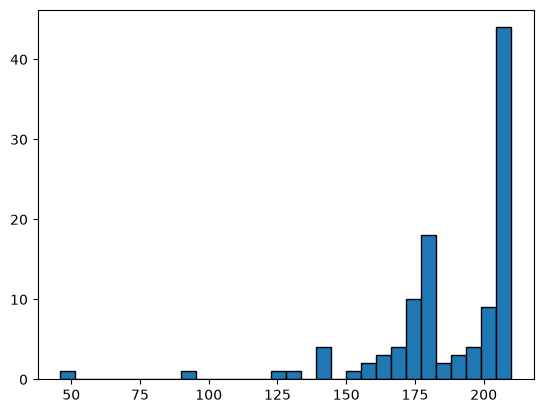

In [34]:
plt.hist(PH_df['number_of_entries'], bins=30, edgecolor='black');

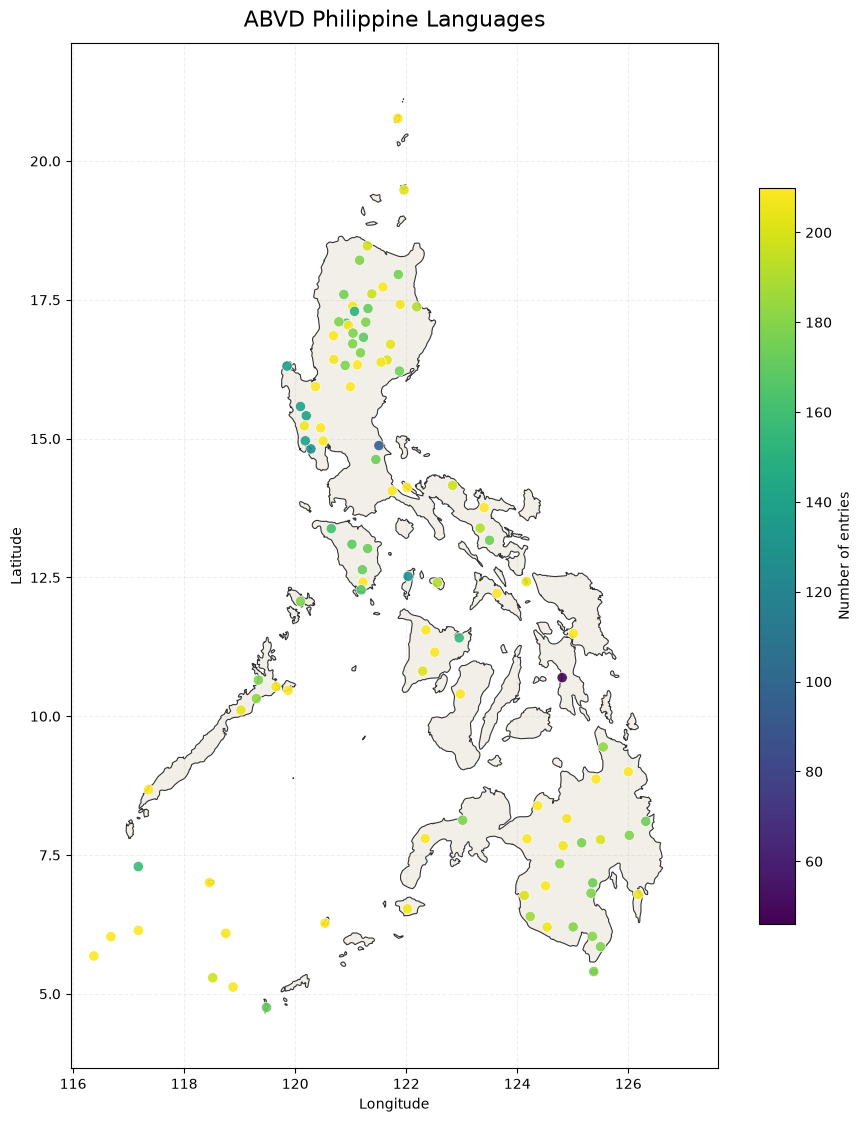

In [59]:
with open(PROJECT_ROOT / 'data' / "countries.geojson", encoding="utf-8") as f:
    countries = json.load(f)

ph_feat = next(
    feature
    for feature in countries["features"]
    if feature["properties"].get("name") == "Philippines"
)
ph_geom = shape(ph_feat["geometry"])

ph_map = gpd.GeoDataFrame(
    {"country": ["Philippines"]},
    geometry=[ph_geom],
    crs="EPSG:4326",
)

plot_df = PH_df.copy()
plot_df["longitude"] = pd.to_numeric(plot_df["longitude"], errors="coerce")
plot_df["latitude"] = pd.to_numeric(plot_df["latitude"], errors="coerce")
plot_df["number_of_entries"] = pd.to_numeric(
    plot_df["number_of_entries"],
    errors="coerce",
)
plot_df = plot_df.dropna(
    subset=["longitude", "latitude", "number_of_entries"]
)

language_points = gpd.GeoDataFrame(
    plot_df,
    geometry=gpd.points_from_xy(
        plot_df["longitude"],
        plot_df["latitude"],
    ),
    crs="EPSG:4326",
)

fig, ax = plt.subplots(figsize=(9, 12))

ph_map.plot(
    ax=ax,
    facecolor="#f2efe9",
    edgecolor="#333333",
    linewidth=0.8,
)

language_points.plot(
    ax=ax,
    column="number_of_entries",
    cmap="viridis",
    edgecolor="white",
    linewidth=0.5,
    markersize=55,
    alpha=0.9,
    legend=True,
    legend_kwds={
        "label": "Number of entries",
        "shrink": 0.65,
    },
    zorder=3,
)

minx, miny, maxx, maxy = ph_geom.bounds
ax.set_xlim(minx - 1, maxx + 1)
ax.set_ylim(miny - 1, maxy + 1)

ax.set_title("ABVD Philippine Languages", fontsize=16, pad=12)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(alpha=0.2, linestyle="--")
ax.set_aspect("equal")

plt.tight_layout()
plt.show()

## loanword indicators found in Philippine annotations

The regular expression below is deliberately visible and editable. It detects explicit source-language names and loan/borrowing terminology in the **Annotation** field only. The separate ABVD `Loan` field is retained in the long-form export but is not used to populate Table 3, matching the requested definition. Detected text is preserved as written in the annotation, deduplicated case-insensitively, and joined with commas.

In [36]:
LOAN_INDICATOR_RE = re.compile(
    r"\b(?:"
    r"Spanish|English|Castilian|Anglicism|"
    r"loan(?:word)?s?|borrow(?:ed|ing)?|"
    r"Malay|Indonesian|Arabic|Chinese|Hokkien|Japanese|"
    r"Portuguese|Dutch|Sanskrit|Tamil|Hindi|French|German|Latin|Persian"
    r")\b",
    flags=re.IGNORECASE,
)

def detect_loan_indicators(annotation: object) -> list[str]:
    if pd.isna(annotation):
        return []

    annotation = str(annotation).strip()
    if not annotation:
        return []

    seen: set[str] = set()
    indicators: list[str] = []

    for match in LOAN_INDICATOR_RE.finditer(annotation):
        detected = match.group(0).strip()
        key = detected.casefold()

        if key not in seen:
            seen.add(key)
            indicators.append(detected)

    return indicators

philippine_ids = set(philippine_records["language_id"])
language_to_merge_key = philippine_records.set_index("language_id")["_merge_key"]
philippine_annotations = raw_entries.loc[
    raw_entries["language_id"].isin(philippine_ids),
    ["language_id", "english_word", "annotation"],
].copy()
philippine_annotations["_merge_key"] = (
    philippine_annotations["language_id"].map(language_to_merge_key)
)
philippine_annotations["detected_indicators"] = (
    philippine_annotations["annotation"]
    .map(detect_loan_indicators)
)
indicator_rows = (philippine_annotations
                  .explode("detected_indicators")
                  .dropna(subset=["detected_indicators", "english_word"]))

if indicator_rows.empty:
    indicators_wide = pd.DataFrame(index=pd.Index([], name="_merge_key"))
else:
    indicators_long = (indicator_rows
                       .groupby(["_merge_key", "english_word"], sort=False)["detected_indicators"]
                       .agg(lambda values: join_unique(values, ", "))
                       .reset_index())
    indicators_wide = indicators_long.pivot(
        index="_merge_key", columns="english_word", values="detected_indicators"
    )
    indicators_wide.columns.name = None

PH_loan = PH_df_internal[["_merge_key"] + metadata_columns].merge(
    indicators_wide, left_on="_merge_key", right_index=True, how="left", validate="one_to_one"
)
PH_loan = PH_loan.reindex(columns=metadata_columns + word_columns)
PH_loan.to_csv(OUTPUT_DIR / "PH_loan.csv", index=False)

detected_cells = int(PH_loan[word_columns].notna().sum().sum())
print(f"Table 3 shape: {PH_loan.shape[0]:,} languages × {PH_loan.shape[1]:,} columns")
print(f"Language/concept cells with annotation indicators: {detected_cells:,}")
display(PH_loan.head())

Table 3 shape: 108 languages × 218 columns
Language/concept cells with annotation indicators: 102


,language_id,language,latitude,longitude,glottocode,author,number_of_entries,source_url,hand,left,...,Five,Six,Seven,Eight,Nine,Ten,Twenty,Fifty,One Hundred,One Thousand
0,409,Agta,17.9571,121.857,cent2084,R. Mayfield in Reid (1971),176,https://abvd.eva.mpg.de/austronesian/language....,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1569,Agutyanen,10.5328,119.655,agut1237,Caabay & Melvin (2018),207,https://abvd.eva.mpg.de/austronesian/language....,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,43,Aklanon - Bisayan,11.5543,122.354,akla1241,Dave Zorc,210,https://abvd.eva.mpg.de/austronesian/language....,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1270,Alangan,13.0982,121.022,alan1249,Barbian (1977),169,https://abvd.eva.mpg.de/austronesian/language....,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1211,Arta,16.4185,121.656,arta1239,Yukinori Kimoto,202,https://abvd.eva.mpg.de/austronesian/language....,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


(array([  1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   1.,   0.,   1.,   0.,   1.,   0.,   1.,   0.,
          1.,   0.,   3.,   0.,  10.,   0.,  28., 163.]),
 array([ 93. ,  93.5,  94. ,  94.5,  95. ,  95.5,  96. ,  96.5,  97. ,
         97.5,  98. ,  98.5,  99. ,  99.5, 100. , 100.5, 101. , 101.5,
        102. , 102.5, 103. , 103.5, 104. , 104.5, 105. , 105.5, 106. ,
        106.5, 107. , 107.5, 108. ]),
 <BarContainer object of 30 artists>)

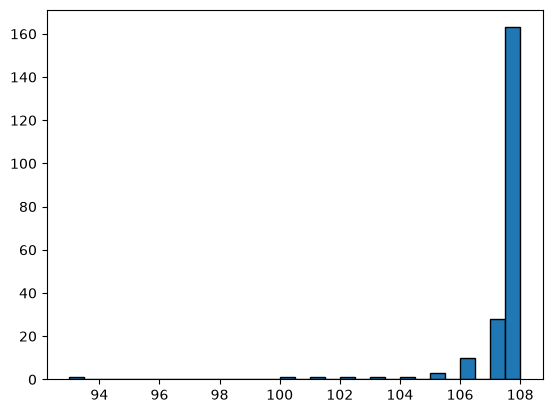

In [37]:
na_counts_PH_loan = (
    PH_loan[word_columns]
    .isna()
    .sum()
    .rename("na_count")
    .rename_axis("english_word")
    .reset_index()
    .sort_values(
        ["na_count", "english_word"],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)

plt.hist(na_counts_PH_loan['na_count'], bins=30, edgecolor='black')

In [38]:
na_counts_PH_loan.na_count.describe()

count    210.000000
mean     107.514286
std        1.484299
min       93.000000
25%      108.000000
50%      108.000000
75%      108.000000
max      108.000000
Name: na_count, dtype: float64

# Expanding detected cognates

In [39]:
PH_confirmed_words = pd.read_csv(OUTPUT_DIR / "confirmed_philippine_loanwords.csv", encoding="utf-8")

In [40]:
PH_confirmed_words

,english_word,detected_loan_words
0,to cook,NaN
1,dry,NaN
2,short,NaN
3,"to tie up, fasten",NaN
4,to scratch,NaN
...,...,...
205,Nine,nuebe
206,Seven,siete; syiti
207,salt,NaN
208,eye,NaN


In [41]:
sum(
    PH_confirmed_words["detected_loan_words"].isna()
)

179

In [42]:
def split_semicolon_values(value):
    if pd.isna(value):
        return []

    return [
        item.strip()
        for item in str(value).split(";")
        if item.strip()
    ]


# Build a lookup from each English concept to its confirmed loanword forms.
confirmed_loan_lookup = {}

for row in PH_confirmed_words.itertuples(index=False):
    english_word = row.english_word
    detected_words = split_semicolon_values(row.detected_loan_words)

    confirmed_loan_lookup.setdefault(english_word, set()).update(
        word.casefold()
        for word in detected_words
    )


# Retain the PH_df metadata and replace each word column with binary values.
PH_final = PH_df.copy()

for english_word in word_columns:
    confirmed_words = confirmed_loan_lookup.get(english_word, set())

    PH_final[english_word] = PH_final[english_word].map(
        lambda cell: int(
            any(
                form.casefold() in confirmed_words
                for form in split_semicolon_values(cell)
            )
        )
    )


# Confirm that every word column contains only 0 or 1.
assert PH_final[word_columns].isin([0, 1]).all().all()

PH_final = PH_final.copy()

PH_final["number_of_loans"] = (
    PH_final[word_columns]
    .sum(axis=1)
    .astype(int)
)

print(f"PH_final shape: {PH_final.shape}")
print(
    "Total detected loanword cells:",
    int(PH_final[word_columns].sum().sum()),
)

display(PH_final.head())

PH_final.to_csv(OUTPUT_DIR / "PH_final.csv", index=False)

PH_final shape: (108, 219)
Total detected loanword cells: 147


,language_id,language,latitude,longitude,glottocode,author,number_of_entries,source_url,hand,left,...,Six,Seven,Eight,Nine,Ten,Twenty,Fifty,One Hundred,One Thousand,number_of_loans
0,409,Agta,17.9571,121.857,cent2084,R. Mayfield in Reid (1971),176,https://abvd.eva.mpg.de/austronesian/language....,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1569,Agutyanen,10.5328,119.655,agut1237,Caabay & Melvin (2018),207,https://abvd.eva.mpg.de/austronesian/language....,0,0,...,0,0,0,0,0,0,0,0,0,3
2,43,Aklanon - Bisayan,11.5543,122.354,akla1241,Dave Zorc,210,https://abvd.eva.mpg.de/austronesian/language....,0,0,...,0,0,0,0,0,0,1,0,0,2
3,1270,Alangan,13.0982,121.022,alan1249,Barbian (1977),169,https://abvd.eva.mpg.de/austronesian/language....,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1211,Arta,16.4185,121.656,arta1239,Yukinori Kimoto,202,https://abvd.eva.mpg.de/austronesian/language....,0,0,...,0,0,0,0,0,0,0,0,0,1


In [43]:
PH_final[['language','number_of_loans']].sort_values('number_of_loans', ascending=False).head(60)

,language,number_of_loans
29,Cebuano,13
84,Pangasinan,9
48,Inabaknon,9
50,"Inati (Hamtic); Inati (Jordan, Guimaras); Inat...",6
16,Bikol (Bisakol); Bikol (Naga City); Naga Bikol,6
82,Marinduque Tagalog; Mindoro Tagalog; Tagalog; ...,6
64,Kamayo,6
96,Surigaonon,6
54,Itawis; Malaweg,5
83,Masbatenyo,5


# Sentiment Analysis

In [44]:
PH_final = pd.read_csv(OUTPUT_DIR / "PH_final.csv", encoding="utf-8")

In [45]:
PH_confirmed_words_senti = PH_confirmed_words[PH_confirmed_words['detected_loan_words'].notna()].copy()

In [46]:
PH_confirmed_words_senti

,english_word,detected_loan_words
7,to throw,etsa; itsa
15,"to know, be knowledgeable",maalamon; ma-antígo; kamaò; kabalò
38,to turn,kurba; kumorba
53,One,uno; un
57,Ten,diis
61,to sew,magsórsi
62,to work,ʔubraʔ; mag-obrá; magtrabáho; mattrabáhu; matt...
71,to think,pamínsar; paminsara
72,Twenty,baynte; bayinti; baínte; binte; veinti; beynte...
82,to hit,paluin; pumalo


## Sentiment Analysis using NRC-VAD

In [47]:
import re
import unicodedata
import pandas as pd


NRC_VAD_DIR = PROJECT_ROOT / 'data' / "NRC-VAD-Lexicon-v2.1"
NRC_VAD_PATH = NRC_VAD_DIR / "NRC-VAD-Lexicon-v2.1.txt"


def normalize_term(value):
    if pd.isna(value):
        return pd.NA

    value = unicodedata.normalize("NFKC", str(value)).casefold()
    value = value.replace("’", "'")
    value = re.sub(r"[-_]+", " ", value)
    value = re.sub(r"[^a-z0-9' ]+", " ", value)
    value = re.sub(r"\s+", " ", value).strip()

    return value if value else pd.NA


NRC_vad = pd.read_csv(
    NRC_VAD_PATH,
    sep="\t",
    encoding="utf-8",
)

# Standardize column names.
NRC_vad.columns = (
    NRC_vad.columns
    .str.strip()
    .str.casefold()
)

required_columns = {"term", "valence", "arousal", "dominance"}
missing_columns = required_columns.difference(NRC_vad.columns)

if missing_columns:
    raise ValueError(
        f"Missing expected columns: {sorted(missing_columns)}. "
        f"Available columns: {NRC_vad.columns.tolist()}"
    )

NRC_vad = NRC_vad[
    ["term", "valence", "arousal", "dominance"]
].copy()

NRC_vad["normalized_term"] = NRC_vad["term"].map(normalize_term)

for dimension in ["valence", "arousal", "dominance"]:
    NRC_vad[dimension] = pd.to_numeric(
        NRC_vad[dimension],
        errors="coerce",
    )

NRC_vad = (
    NRC_vad
    .dropna(
        subset=[
            "normalized_term",
            "valence",
            "arousal",
            "dominance",
        ]
    )
    .drop_duplicates("normalized_term")
    .reset_index(drop=True)
)

vad_lookup = NRC_vad.set_index("normalized_term")[
    ["valence", "arousal", "dominance"]
]

print(f"Loaded {len(NRC_vad):,} NRC VAD terms")
print(
    NRC_vad[["valence", "arousal", "dominance"]]
    .agg(["min", "max"])
)

display(NRC_vad.head())

Loaded 54,797 NRC VAD terms
     valence  arousal  dominance
min     -1.0     -1.0       -1.0
max      1.0      1.0        1.0


,term,valence,arousal,dominance,normalized_term
0,a battery,0.134,-0.298,-0.096,a battery
1,a bit,-0.096,-0.264,-0.214,a bit
2,a bunch,0.088,-0.350,-0.068,a bunch
3,a cappella,0.134,-0.116,-0.200,a cappella
4,a couple,0.266,-0.110,0.090,a couple


In [48]:
def unique_in_order(values):
    seen = set()
    output = []

    for value in values:
        if value is pd.NA or pd.isna(value):
            continue

        if value not in seen:
            seen.add(value)
            output.append(value)

    return output


def gloss_candidates(gloss):
    """
    Generate conservative NRC lookup candidates.

    Examples:
        'meat/flesh'       -> meat, flesh
        'to die, be dead'  -> to die, die, be dead, dead
    """
    if pd.isna(gloss):
        return []

    raw_gloss = unicodedata.normalize("NFKC", str(gloss)).casefold()

    # Include both the surrounding gloss and parenthetical alternatives.
    parenthetical_terms = re.findall(r"\(([^)]+)\)", raw_gloss)
    without_parentheses = re.sub(r"\([^)]+\)", " ", raw_gloss)

    raw_candidates = [without_parentheses, *parenthetical_terms]

    for expression in [without_parentheses, *parenthetical_terms]:
        raw_candidates.extend(
            re.split(r"\s*(?:/|;|,|\bor\b)\s*", expression)
        )

    expanded_candidates = []

    for candidate in raw_candidates:
        candidate = normalize_term(candidate)

        if candidate is pd.NA or pd.isna(candidate):
            continue

        expanded_candidates.append(candidate)

        # Add variants without common dictionary-style verb prefixes.
        for prefix in ("to be ", "to ", "be "):
            if candidate.startswith(prefix):
                stripped = candidate[len(prefix):].strip()
                if stripped:
                    expanded_candidates.append(stripped)

    return unique_in_order(expanded_candidates)


def find_vad_scores(gloss):
    candidates = gloss_candidates(gloss)

    if not candidates:
        return pd.Series({
            "valence": pd.NA,
            "arousal": pd.NA,
            "dominance": pd.NA,
            "vad_matched_terms": pd.NA,
            "vad_match_method": "unmatched",
        })

    # Prefer an exact match for the complete normalized gloss.
    exact_candidate = normalize_term(gloss)

    if exact_candidate in vad_lookup.index:
        scores = vad_lookup.loc[exact_candidate]

        return pd.Series({
            "valence": scores["valence"],
            "arousal": scores["arousal"],
            "dominance": scores["dominance"],
            "vad_matched_terms": exact_candidate,
            "vad_match_method": "exact",
        })

    # Otherwise average scores from matched gloss components.
    matched_terms = [
        candidate
        for candidate in candidates
        if candidate in vad_lookup.index
    ]
    matched_terms = unique_in_order(matched_terms)

    if not matched_terms:
        return pd.Series({
            "valence": pd.NA,
            "arousal": pd.NA,
            "dominance": pd.NA,
            "vad_matched_terms": pd.NA,
            "vad_match_method": "unmatched",
        })

    scores = vad_lookup.loc[matched_terms].mean(axis=0)

    return pd.Series({
        "valence": scores["valence"],
        "arousal": scores["arousal"],
        "dominance": scores["dominance"],
        "vad_matched_terms": "; ".join(matched_terms),
        "vad_match_method": "component_average",
    })


def count_unique_semicolon_words(value):
    if pd.isna(value):
        return 0

    words = {
        word.strip().casefold()
        for word in str(value).split(";")
        if word.strip()
    }

    return len(words)


PH_vad = PH_confirmed_words_senti.copy()

PH_vad["n_confirmed_loanwords"] = (
    PH_vad["detected_loan_words"]
    .map(count_unique_semicolon_words)
)

vad_results = PH_vad["english_word"].apply(find_vad_scores)

PH_vad = pd.concat(
    [
        PH_vad.reset_index(drop=True),
        vad_results.reset_index(drop=True),
    ],
    axis=1,
)

matched_n = PH_vad["valence"].notna().sum()
total_n = len(PH_vad)

print(f"NRC VAD coverage: {matched_n:,} of {total_n:,} meanings")
print(f"Coverage percentage: {matched_n / total_n:.1%}")

print("\nUnmatched meanings:")
display(
    PH_vad.loc[
        PH_vad["valence"].isna(),
        ["english_word", "detected_loan_words"],
    ]
)

display(PH_vad.head())

NRC VAD coverage: 31 of 31 meanings
Coverage percentage: 100.0%

Unmatched meanings:


,english_word,detected_loan_words


,english_word,detected_loan_words,n_confirmed_loanwords,valence,arousal,dominance,vad_matched_terms,vad_match_method
0,to throw,etsa; itsa,2,-0.312,0.540,0.246,throw,component_average
1,"to know, be knowledgeable",maalamon; ma-antígo; kamaò; kabalò,4,0.630,-0.184,0.676,know; knowledgeable,component_average
2,to turn,kurba; kumorba,2,0.062,-0.204,-0.036,turn,component_average
3,One,uno; un,2,0.084,-0.416,-0.260,one,exact
4,Ten,diis,1,0.124,-0.480,-0.188,ten,exact


In [52]:
import numpy as np
import pandas as pd


loan_binary = (
    PH_final[word_columns]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
    .gt(0)
    .astype(int)
)

languages_per_meaning = (
    loan_binary
    .sum(axis=0)
    .astype(int)
    .rename("n_languages_with_loan")
)

vad_plot_df = (
    PH_vad
    .dropna(subset=["valence", "arousal", "dominance"])
    .copy()
    .reset_index(drop=True)
)

vad_plot_df["n_languages_with_loan"] = (
    vad_plot_df["english_word"]
    .map(languages_per_meaning)
    .fillna(0)
    .astype(int)
)

# Keep zero-count points visible, while retaining the true count separately.
vad_plot_df["plot_size"] = (
    vad_plot_df["n_languages_with_loan"]
    .clip(lower=1)
)

display(
    vad_plot_df[
        [
            "english_word",
            "detected_loan_words",
            "n_languages_with_loan",
        ]
    ]
    .sort_values("n_languages_with_loan", ascending=False)
    .reset_index(drop=True)
)

,english_word,detected_loan_words,n_languages_with_loan
0,green,birdi; be:rdi; berde; birˈdi; 'birdi; hilaw; l...,24
1,to work,ʔubraʔ; mag-obrá; magtrabáho; mattrabáhu; matt...,24
2,meat/flesh,karne; karni +t+d1; karni; carne; kárne; kal'n...,16
3,"correct, true",ustu; hustu; támâ; totoó; tutoqó; tama; totoo;...,13
4,Fifty,singkwénta; singkwenta; cincuenta; cinquenta; ...,10
5,fruit,proˈtas; protas; prutas,8
6,Twenty,baynte; bayinti; baínte; binte; veinti; beynte...,8
7,"to open, uncover",abrih; ʔábri; abri +d1; abríhan; abri,5
8,fat/grease,mantíka; sebo; grasa; mantika,5
9,One Thousand,mil,3


In [53]:
import plotly.express as px


fig_interactive = px.scatter(
    vad_plot_df,
    x="valence",
    y="arousal",
    color="dominance",
    size="plot_size",
    hover_name="english_word",
    hover_data={
        "detected_loan_words": True,
        "n_languages_with_loan": True,
        "valence": ":.3f",
        "arousal": ":.3f",
        "dominance": ":.3f",
        "vad_matched_terms": True,
        "vad_match_method": True,
        "plot_size": False,
    },
    range_x=[-1, 1],
    range_y=[-1, 1],
    range_color=[-1, 1],
    color_continuous_scale="RdBu_r",
    size_max=38,
    labels={
        "valence": "Valence: negative ← → positive",
        "arousal": "Arousal: inactive ← → active",
        "dominance": "Dominance",
        "n_languages_with_loan": "Languages containing loanword",
    },
    title="Affective Space of Meanings with Confirmed Loanwords",
)

fig_interactive.add_vline(
    x=0,
    line_width=1,
    line_dash="dash",
    line_color="gray",
)

fig_interactive.add_hline(
    y=0,
    line_width=1,
    line_dash="dash",
    line_color="gray",
)

fig_interactive.update_traces(
    marker={
        "opacity": 0.8,
        "line": {
            "width": 0.7,
            "color": "white",
        },
    }
)

fig_interactive.update_layout(
    width=1000,
    height=750,
    template="plotly_white",
    coloraxis_colorbar={
        "title": "Dominance",
        "tickvals": [-1, 0, 1],
        "ticktext": ["Weak", "Neutral", "Powerful"],
    },
)

fig_interactive.update_yaxes(
    scaleanchor="x",
    scaleratio=1,
)

fig_interactive.show()

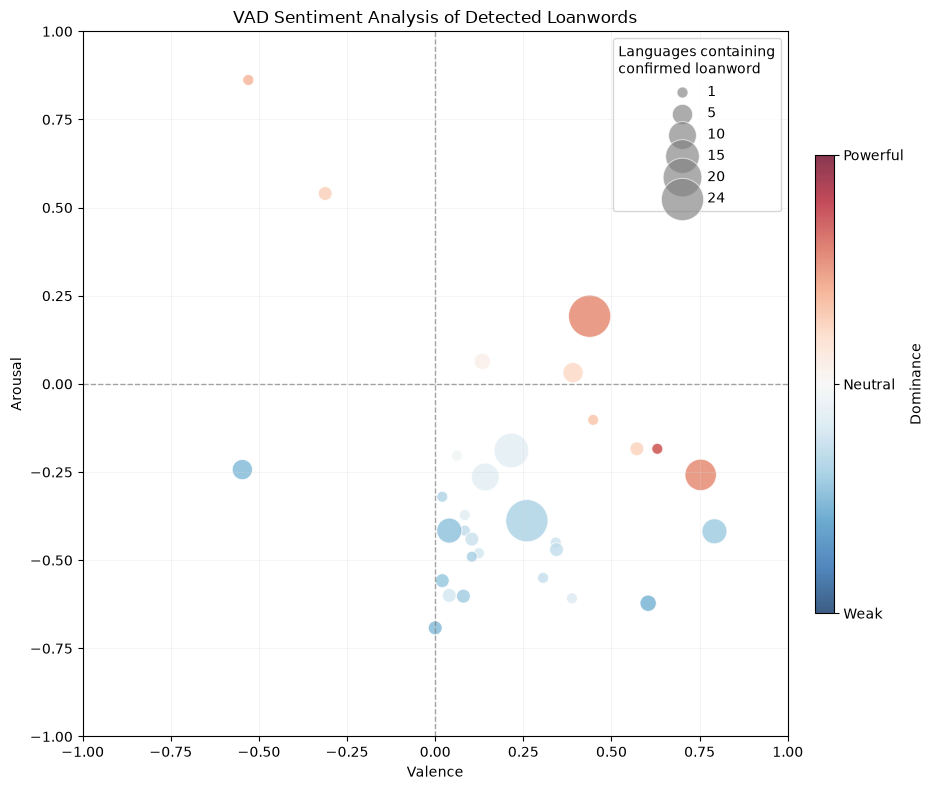

In [60]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize


language_counts = vad_plot_df["n_languages_with_loan"].to_numpy()

maximum_count = max(int(language_counts.max()), 1)
size_scale = min(45, 900 / maximum_count)
point_sizes = 25 + language_counts * size_scale

fig_static, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(
    vad_plot_df["valence"],
    vad_plot_df["arousal"],
    c=vad_plot_df["dominance"],
    s=point_sizes,
    cmap="RdBu_r",
    norm=Normalize(vmin=-1, vmax=1),
    alpha=0.78,
    edgecolor="white",
    linewidth=0.7,
)

ax.axvline(
    0,
    color="gray",
    linestyle="--",
    linewidth=1,
    alpha=0.7,
)

ax.axhline(
    0,
    color="gray",
    linestyle="--",
    linewidth=1,
    alpha=0.7,
)

ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_aspect("equal", adjustable="box")

ax.set_xlabel("Valence")
ax.set_ylabel("Arousal")
ax.set_title("VAD Sentiment Analysis of Detected Loanwords")

ax.grid(
    color="lightgray",
    linewidth=0.5,
    alpha=0.35,
)

colorbar = fig_static.colorbar(
    scatter,
    ax=ax,
    shrink=0.65,   # 65% of the original height
    aspect=25,     # larger values make it thinner
    pad=0.03,
)


colorbar.set_label("Dominance")
colorbar.set_ticks([-1, 0, 1])
colorbar.set_ticklabels(["Weak", "Neutral", "Powerful"])

# Representative numbers of languages.
preferred_breaks = [1, 5, 10, 15, 20, 25, maximum_count]

legend_counts = sorted({
    count
    for count in preferred_breaks
    if 1 <= count <= maximum_count
})

size_handles = [
    ax.scatter(
        [],
        [],
        s=25 + count * size_scale,
        color="gray",
        alpha=0.65,
        edgecolor="white",
        linewidth=0.7,
        label=str(count),
    )
    for count in legend_counts
]

if size_handles:
    ax.legend(
        handles=size_handles,
        title="Languages containing\nconfirmed loanword",
        loc="upper right",
        frameon=True,
    )

fig_static.tight_layout()
plt.show()